In [1]:
import numpy as np
import math
import itertools
import matplotlib.pyplot as plt

# ---------------------
# Global System Parameters
# ---------------------
N = 3         # number of channels
L = 3         # maximum load per channel (levels: 1,2,3)
K = 9         # total number of users (assume K = N*L for simplicity)

# True means for each channel and load level.
# Shape: (N, L), where index l corresponds to load level l+1.
mu_true = np.array([[0.9, 0.8, 0.6],   # Channel 1
                    [0.8, 0.7, 0.5],    # Channel 2
                    [0.7, 0.6, 0.4]])   # Channel 3

# Clipping bounds for rewards
clip_low, clip_high = 0.0, 1.0

# ---------------------
# Simulation Parameters (will vary these in experiments)
# ---------------------
# Default variance and Delta - these will be overwritten in experiments.
default_var = 0.01        # variance for reward generation
default_Delta = 0.05      # target estimation accuracy

# Number of simulation runs (for averaging)
num_runs = 1

# Time horizon for simulation
T_sim = 100000

# ---------------------
# Functions
# ---------------------
def clip_rewards(rewards):
    return np.clip(rewards, clip_low, clip_high)

def sample_rewards(mu, n_samples, std):
    """Generate n_samples from Normal(mu, std) and clip to [0,1]."""
    samples = np.random.normal(mu, std, n_samples)
    return clip_rewards(samples)

def compute_T0(T, sigma2, Delta):
    """Compute the per-configuration sample size based on Bernstein."""
    # Use: T0 = ((2*sigma^2 + (2/3)*Delta) / Delta^2) * log(T+1)
    return int((2 * sigma2 + (2/3)*Delta) / (Delta**2) *np.log10(T))

def estimate_means(T0, mu_matrix, sigma2, Delta):
    """For each configuration (channel m, load l), take T0 samples and compute sample mean."""
    (N, L) = mu_matrix.shape
    std = math.sqrt(sigma2)
    est = np.zeros((N, L))
    for m in range(N):
        for l in range(L):
            samples = sample_rewards(mu_matrix[m, l], T0, std)
            est[m, l] = np.mean(samples)
    return est

def feasible_allocations(N, L, K):
    allocs = []
    for alloc in itertools.product(range(L+1), repeat=N):
        if sum(alloc) == K:
            allocs.append(alloc)
    return allocs

def compute_total_reward(alloc, mean_matrix):
    total = 0.0
    for m, k in enumerate(alloc):
        if k > 0:
            total += k * mean_matrix[m, k-1]
    return total

def get_optimal_allocation(mean_matrix):
    allocs = feasible_allocations(N, L, K)
    best_alloc = None
    best_reward = -np.inf
    for alloc in allocs:
        r = compute_total_reward(alloc, mean_matrix)
        if r > best_reward:
            best_reward = r
            best_alloc = alloc
    return best_alloc, best_reward

def simulate_proposed(T, sigma2=default_var, Delta=default_Delta):
    """
    Simulate one run of the proposed algorithm over a horizon T.
    The algorithm consists of one estimation phase and one allocation phase.
    Returns the total regret.
    """
    std = math.sqrt(sigma2)
    T0 = compute_T0(T, sigma2, Delta)
    T_e = N * L * T0  # total slots in estimation phase
    T_a = max(T - T_e, 0)
    
    # Estimation phase: collect samples for each (m, l)
    est_means = estimate_means(T0, mu_true, sigma2, Delta)
    # Estimated optimal allocation from the estimated means.
    est_alloc, _ = get_optimal_allocation(est_means)
    # True (oracle) optimal allocation and per-slot reward
    true_alloc, true_alloc_reward = get_optimal_allocation(mu_true)
    
    # Simulate allocation phase with the estimated allocation.
    reward_alloc = 0.0
    for _ in range(T_a):
        slot_reward = 0.0
        for m, k in enumerate(est_alloc):
            if k > 0:
                # Use true rewards for channel m corresponding to load level k.
                samples = sample_rewards(mu_true[m, k-1], k, std)
                slot_reward += np.sum(samples)
        reward_alloc += slot_reward
        
    # For the estimation phase, instead of assuming worst-case, we simulate the actual reward.
    reward_estimation = 0.0
    for m in range(N):
        for l in range(L):
            samples = sample_rewards(mu_true[m, l], T0, std)
            reward_estimation += np.sum(samples)
    
    total_reward = reward_estimation + reward_alloc
    # Oracle reward if optimal allocation is used for all T slots.
    oracle_total_reward = true_alloc_reward * T
    regret = oracle_total_reward - total_reward
    return regret

def simulate_random(T, sigma2=default_var):
    """
    Simulate one run of a baseline random selection strategy over T slots.
    Each user picks a channel uniformly at random in each slot.
    Returns the regret relative to the oracle.
    """
    std = math.sqrt(sigma2)
    # Oracle optimal allocation reward (per slot)
    _, true_alloc_reward = get_optimal_allocation(mu_true)
    oracle_total_reward = true_alloc_reward * T
    
    total_reward = 0.0
    for t in range(T):
        # Random channel selection for each of K users.
        channel_choices = np.random.choice(N, K)
        loads = [np.sum(channel_choices == m) for m in range(N)]
        slot_reward = 0.0
        for m, k in enumerate(loads):
            if k > 0:
                effective_load = min(k, L)
                samples = sample_rewards(mu_true[m, effective_load-1], effective_load, std)
                slot_reward += np.sum(samples)
        total_reward += slot_reward
    regret = oracle_total_reward - total_reward
    return regret

# ---------------------
# Experiments: Effect of Variance and Delta on Regret
# ---------------------

# Experiment 1: Varying Variance while keeping Delta fixed
variance_values = [0.01, 0.05, 0.1, 0.25]  # from low variance to worst-case
regrets_variance = []




In [2]:
'''
for var in variance_values:
    reg_list = []
    for _ in range(num_runs):
        reg_list.append(simulate_proposed(T_sim, sigma2=var, Delta=default_Delta))
    avg_reg = np.mean(reg_list)
    regrets_variance.append(avg_reg)
 
plt.figure(figsize=(8,5))
plt.plot(variance_values, regrets_variance, marker='o')
plt.xlabel('Variance $\sigma^2$')
plt.ylabel('Average Cumulative Regret')
plt.title('Effect of Variance on Regret (Delta = {})'.format(default_Delta))
plt.grid(True)
plt.show()

# Experiment 2: Varying Delta while keeping Variance fixed
delta_values = [0.01, 0.03, 0.05, 0.1, 0.2]  # varying reward gap
regrets_delta = []

for d in delta_values:
    reg_list = []
    for _ in range(num_runs):
        reg_list.append(simulate_proposed(T_sim, sigma2=default_var, Delta=d))
    avg_reg = np.mean(reg_list)
    regrets_delta.append(avg_reg)

plt.figure(figsize=(8,5))
plt.plot(delta_values, regrets_delta, marker='s')
plt.xlabel('Delta')
plt.ylabel('Average Cumulative Regret')
plt.title('Effect of Delta on Regret (Variance = {})'.format(default_var))
plt.grid(True)
plt.show()

''';

In [3]:
'''
fig, axs = plt.subplots(2)

axs[0].plot(variance_values, regrets_variance, marker='o')
axs[0].set_xlabel('Variance $\sigma^2$')
axs[0].set_ylabel('Average Cumulative Regret')
axs[0].set_title('Effect of Variance on Regret (Delta = {})'.format(default_Delta))
axs[0].grid()
axs[1].plot(delta_values, regrets_delta, marker='s')
axs[1].set_xlabel('Delta')
axs[1].set_ylabel('Average Cumulative Regret')
axs[1].set_title('Effect of Delta on Regret (Variance = {})'.format(default_var))
axs[1].grid()
plt.tight_layout()
''';

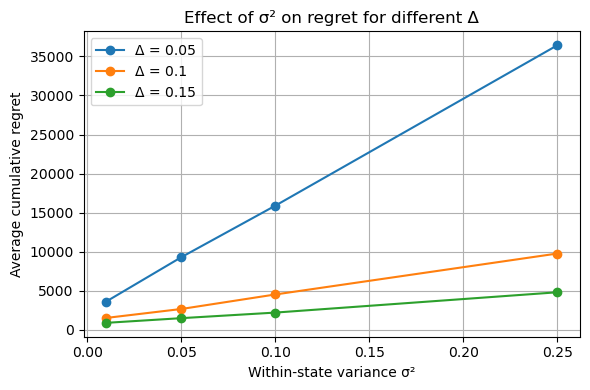

In [4]:
variance_values = [0.01, 0.05, 0.1, 0.25]  # from low variance to worst-case
delta_values    = [0.05, 0.1, 0.15]             

plt.figure(figsize=(6,4))

for delta in delta_values:
    avg_regrets = []
    for var in variance_values:
        # run multiple times for each (var, delta)
        reps = [ simulate_proposed(T_sim, sigma2=var, Delta=delta)
                 for _ in range(num_runs) ]
        avg_regrets.append(np.mean(reps))
    plt.plot(variance_values, avg_regrets, marker='o', label=f'Δ = {delta}')

plt.xlabel('Within‐state variance σ²')
plt.ylabel('Average cumulative regret')
plt.title('Effect of σ² on regret for different Δ')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

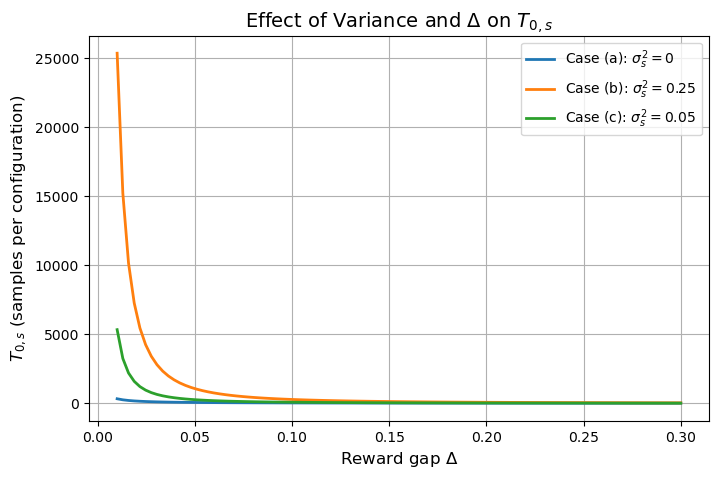

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Set the time horizon T used in the computation of T0,s (a constant factor in practice)
T = 1e5  # e.g., T = 100000

# Define function to compute T0,s based on within-state variance (sigma2) and gap Delta.
def compute_T0_state(sigma2, Delta, T):
    # Using: T0,s = (2*sigma2 + (2/3)*Delta) / (Delta^2) * log(T+1)
    return (2*sigma2 + (2/3)*Delta) / (Delta**2) * np.log10(T)

# Define range of Delta values to explore
Delta_values = np.linspace(0.01, 0.3, 100)

# Case (a): full variance explained => sigma_s^2 = 0
sigma_a = 0.0
T0_a = [compute_T0_state(sigma_a, d, T) for d in Delta_values]

# Case (b): no variance reduction => sigma_s^2 = sigma^2, with worst-case sigma^2 = 0.25
sigma_b = 0.25
T0_b = [compute_T0_state(sigma_b, d, T) for d in Delta_values]

# Case (c): intermediate regime => for example, sigma_s^2 = 0.05 
sigma_c = 0.05
T0_c = [compute_T0_state(sigma_c, d, T) for d in Delta_values]

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(Delta_values, T0_a, label=r'Case (a): $\sigma_s^2=0$', linewidth=2)
plt.plot(Delta_values, T0_b, label=r'Case (b): $\sigma_s^2=0.25$', linewidth=2)
plt.plot(Delta_values, T0_c, label=r'Case (c): $\sigma_s^2=0.05$', linewidth=2)
plt.xlabel(r'Reward gap $\Delta$', fontsize=12)
plt.ylabel(r'$T_{0,s}$ (samples per configuration)', fontsize=12)
plt.title(r'Effect of Variance and $\Delta$ on $T_{0,s}$', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


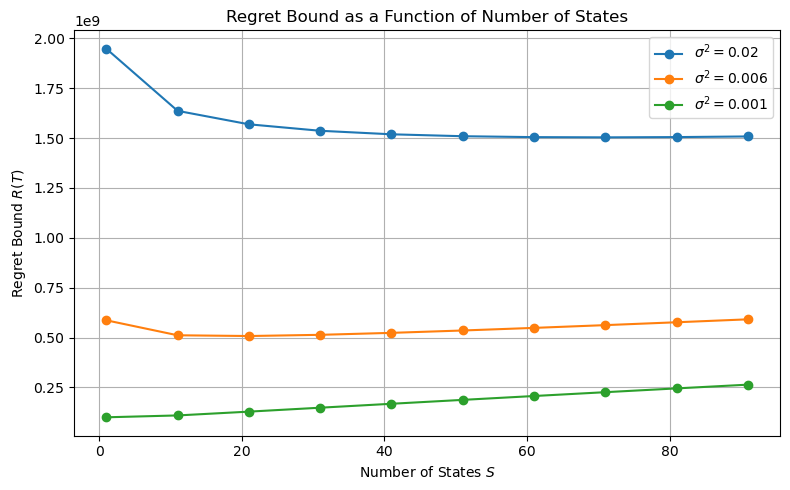

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
K = 9
N = 3
L = 3
T = 1e6
Delta = 1e-4

# Overall variances to sweep
sigma2_list = [0.02, 0.006, 0.001]

# Range of state counts
S_values = np.arange(1, 101, 10)  # from 1 to 2000 in steps of 50

# Prepare the plot
plt.figure(figsize=(8, 5))

for sigma2 in sigma2_list:
    R_vals = []
    for S in S_values:
        sigma_s2 = sigma2 / S
        a_s = Delta**2 / (2 * sigma_s2 + (2/3) * Delta)

        # Compute the product S*K*N*L
        SKNL = S * K * N * L

        # Compute the two terms of the regret bound
        first_term = (SKNL / a_s) * np.log10(T / S)
        second_term = K * S

        R = first_term + second_term
        R_vals.append(R)
    plt.plot(S_values, R_vals, marker='o', label=f'$\\sigma^2={sigma2}$')

plt.xlabel('Number of States $S$')
plt.ylabel('Regret Bound $R(T)$')
plt.title('Regret Bound as a Function of Number of States')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
